In [ ]:
from pathlib import Path
from IPython.core.display import display
# import OvizioApi
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.3)
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from cellface.storage.container import Raw
from cellface.storage.file import BinFile

In [10]:
# base_path = Path("F:\\Experiments\\CaptureTests")
# base_bin_path = Path("F:\\bin_files\\CaptureTests")

base_path = Path("/nas/lrz/LRZ_CELLFACE/02_Image analysis/CaptureTests")
base_bin_path = Path("/nas/lrz/LRZ_CELLFACE/02_Image analysis/CaptureTests/bin_files")

orig_capture_path = base_path / "Capture 2.h5"
orig_otf_bin_path = base_bin_path / "bin_files_otf"
orig_osone_bin_path = base_bin_path / "bin_files_osone"
orig_api_bin_path = base_bin_path / "bin_files_api"

raw_path = base_path / "Capture 2.raw"
raw_bin_path = base_bin_path / "bin_files_raw"
raw_float16_bin_path = base_bin_path / "bin_files_float16_raw"

clone_capture_path = base_path / "Capture 2 clone.h5"
clone_osone_bin_path = base_bin_path / "bin_files_clone_osone"
clone_api_bin_path = base_bin_path / "bin_files_clone_api"

In [11]:
# Bin Files Api Utils
def get_phase(path, index, invert=False):
    image = OvizioApi.reconstruct_phase(str(path), index)
    if invert:
        return -1. * image
    return image


def build_path(base_path, meta_type, capture_nr, n_elements, index):
    zeros = len(str(n_elements))
    index = str(index+1).zfill(zeros)
    p = base_path
    p /= "Capture {:d}".format(capture_nr)
    p = str(p)
    if meta_type == "phase":
        p += "_Phase_"
    elif meta_type == "amplitude":
        p += "_Intensity_"
    p += "t{:s}_d0.00.bin".format(index)
    return p

def write_bin(path, data):
    # Get the matrix dimensions
    height = data.shape[0]
    width = data.shape[1]
    # Write the file in the Ovizio specific manner
    with open(path, "wb") as bin_file:
        bin_file.write(np.uint32(width))
        bin_file.write(np.uint32(height))
        bin_file.write(data)

capture = 2
N = 100

In [ ]:
# Orig Bin Files Api
Path(orig_api_bin_path).mkdir(parents=True, exist_ok=True)

for j in tqdm(range(N)):
    phase_path = build_path(orig_api_bin_path, 'phase', capture, N, j)
    pha = get_phase(orig_capture_path, j, invert=True)
    write_bin(phase_path, pha)

In [ ]:
# Create Raw Container
# Open a raw container in writing mode
with Raw(raw_path, mode='w') as raw:
    # Create the initial structure
    raw.create_structure()
    # The structure will be accessible via the content attribute
    raw.content

    # Now, fill the empty structure with data
    # Load the Hologram Images from the capture
    raw.content.hologram.load_from_capture(orig_capture_path)
    # Load the phase images from the bin folder
    raw.content.phase.images.load_from_bin_folder(orig_api_bin_path)
    # Load the amplitude images from the bin folder
    # raw.content.amplitude.images.load_from_bin_folder(orig_api_bin_path)
    # Load additional Meta Data
    # raw.content.metadata.load_attributes_from_xml(orig_api_bin_path / "Capture 2 metadata.xml")

    # Verify that everything is stored correctly
    correct, error_dict = raw.content.verify_structure(recursive=True)
    display(f"Validity of the content: {correct}")
    display(error_dict)



In [ ]:
# Export Capture from Raw Container

Path(raw_bin_path).mkdir(parents=True, exist_ok=True)

with Raw(raw_path, mode='r') as raw:
    # Export all images of a kind
    raw.content.phase.images.write_to_bin_folder(raw_bin_path)
    # Export the all the holograms as a Capture file
    raw.content.hologram.write_to_capture(clone_capture_path)

In [ ]:
# Clone Bin Files Api
Path(clone_api_bin_path).mkdir(parents=True, exist_ok=True)

for j in tqdm(range(N)):
    phase_path = build_path(clone_api_bin_path, 'phase', capture, N, j)
    pha = get_phase(clone_capture_path, j, invert=True)
    write_bin(phase_path, pha)


In [ ]:
# Raw Float16 Bins
Path(raw_float16_bin_path).mkdir(parents=True, exist_ok=True)

with Raw(raw_path, mode='r') as raw:
    for j, image in enumerate(raw.content.phase.images):
        phase_path = build_path(raw_float16_bin_path, 'phase', capture, N, j)
        write_bin(phase_path, image.astype(np.float16).astype(np.float32))

In [12]:
# Bin Comparison
bin_path_template_dict = {
    "orig_otf_bin": lambda *, image_number: orig_otf_bin_path / f"Capture 2_Phase_t{image_number:d}_d0.00.bin",
    "orig_osone_bin": lambda *, image_number: orig_osone_bin_path / f"Capture 2_Phase_t{image_number:04d}_d0,00.bin",
    "orig_api_bin": lambda *, image_number: orig_api_bin_path / f"Capture 2_Phase_t{image_number:03d}_d0.00.bin",
    "raw_bin": lambda *, image_number: raw_bin_path / f"Capture 2_Phase_t{image_number:03d}_d0.00.bin",
    "raw_float16_bin": lambda *, image_number: raw_float16_bin_path / f"Capture 2_Phase_t{image_number:03d}_d0.00.bin",
    "clone_osone_bin": lambda *, image_number: clone_osone_bin_path / f"Capture 2 clone_Phase_t{image_number:04d}_d0,00.bin",
    "clone_api_bin": lambda *, image_number: clone_api_bin_path / f"Capture 2_Phase_t{image_number:03d}_d0.00.bin"
}
bin_comparison_results = {
    "orig_otf_bin": [],
    "orig_osone_bin": [],
    "orig_api_bin": [],
    "raw_bin": [],
    "raw_float16_bin": [],
    "clone_osone_bin": [],
    "clone_api_bin": []
}

In [149]:
for i in tqdm(range(N)):
    ground_truth = BinFile("phase").location(bin_path_template_dict["orig_api_bin"](image_number=i+1)).read()
    for name, path in bin_path_template_dict.items():
        bin = BinFile("phase").location(path(image_number=i+1)).read()
        bin_comparison_results[name].append(np.abs(np.sum(ground_truth - bin)))

print(f"Mean Errors over {N} samples!\n\n")

for name, results_list in bin_comparison_results.items():
    print(f"{name}: {np.mean(results_list)}\n")

df = pd.DataFrame(bin_comparison_results)

  0%|          | 0/100 [00:00<?, ?it/s]

Mean Errors over 100 samples!


orig_otf_bin: 0.13747376203536987

orig_osone_bin: 0.06112365797162056

orig_api_bin: 0.0

raw_bin: 0.0

raw_float16_bin: 0.01890777423977852

clone_osone_bin: 0.06112365797162056

clone_api_bin: 0.0



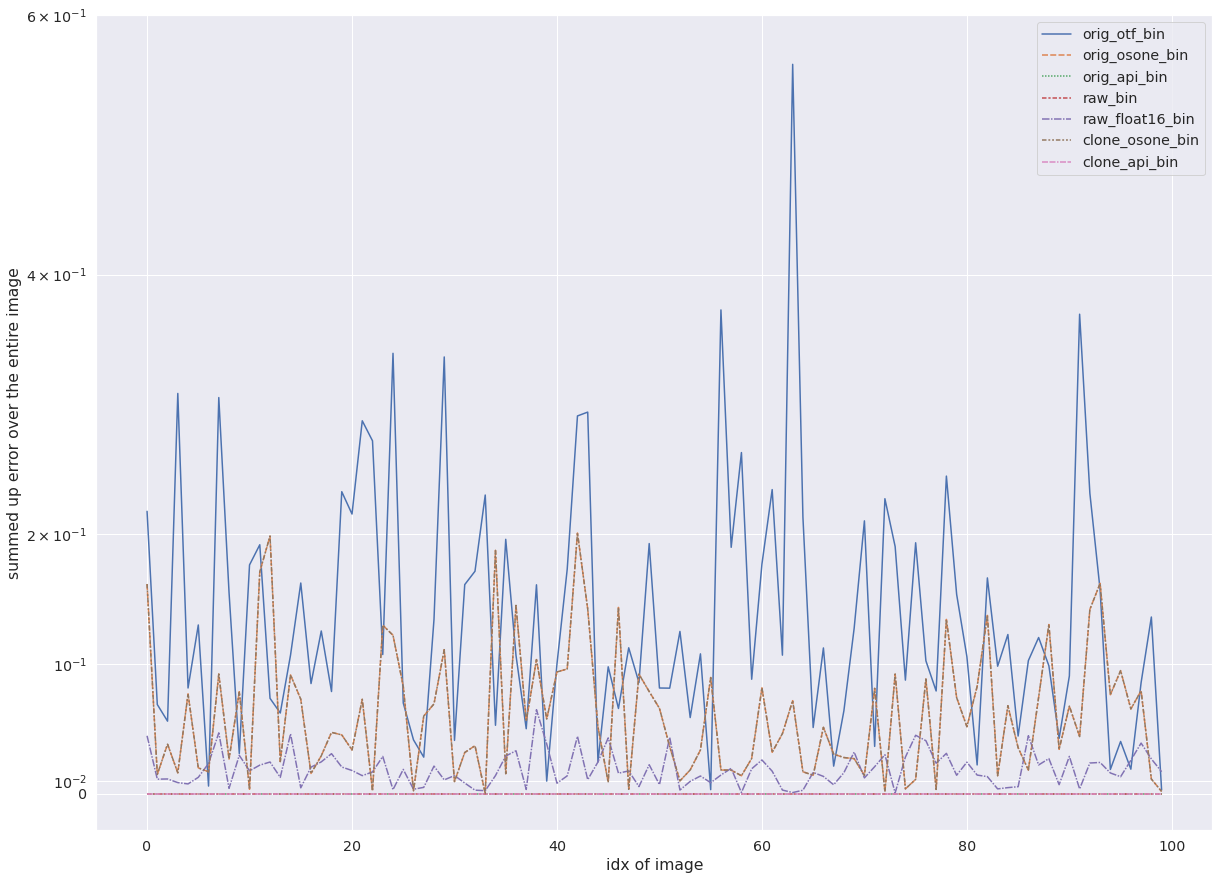

In [126]:
plt.figure(figsize=(20,15))
fig = sns.lineplot(data=df)
plt.yscale("symlog")
fig.set_yticks((0.0, 1e-2, 1e-1, 0.2e0, 0.4e0, 0.6e0))
plt.xlabel("idx of image")
plt.ylabel("summed up error over the entire image")
plt.show()

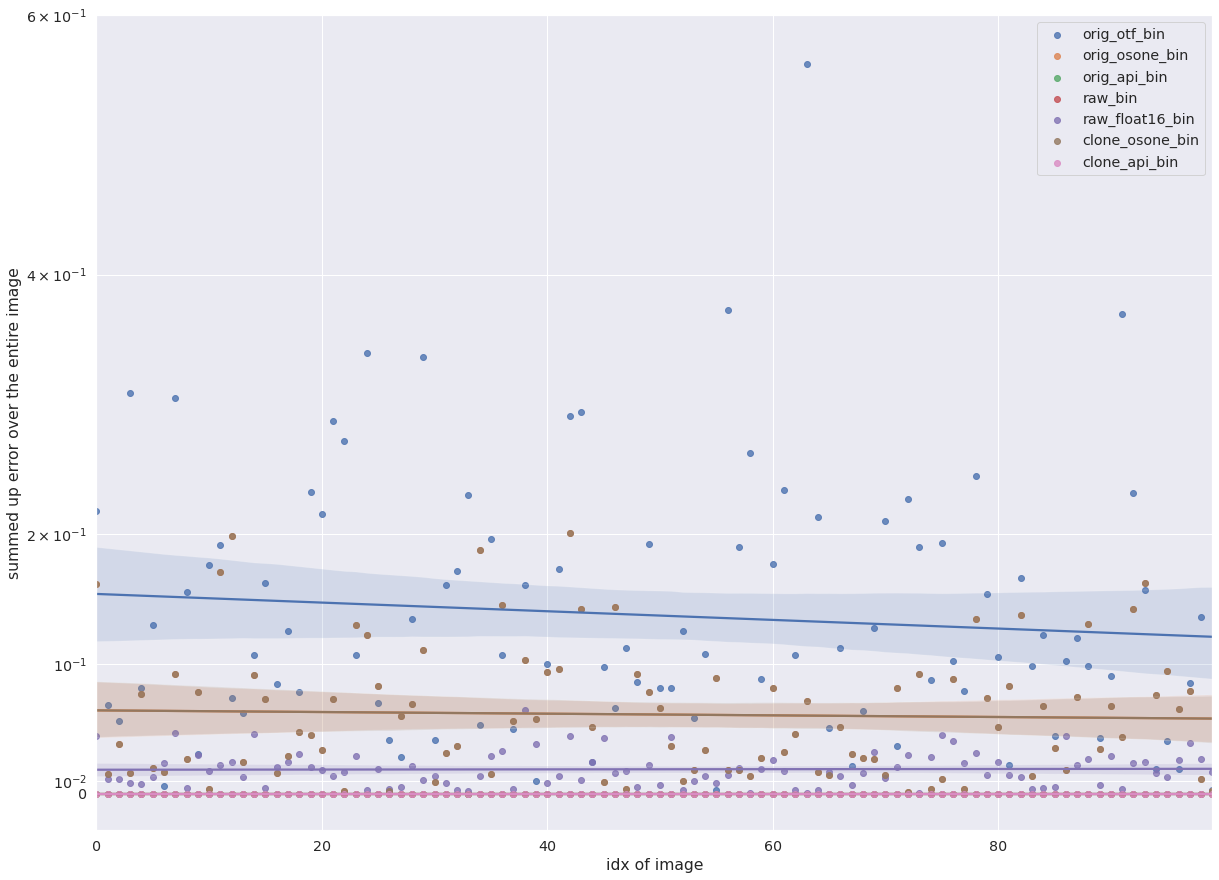

In [125]:
plt.figure(figsize=(20,15))
for key in df.columns:
    fig = sns.regplot(data=df, x=df.index, y=key, label=key)
plt.yscale("symlog")
fig.set_yticks((0.0, 1e-2, 1e-1, 0.2e0, 0.4e0, 0.6e0))
fig.legend()
plt.xlabel("idx of image")
plt.ylabel("summed up error over the entire image")
plt.show()

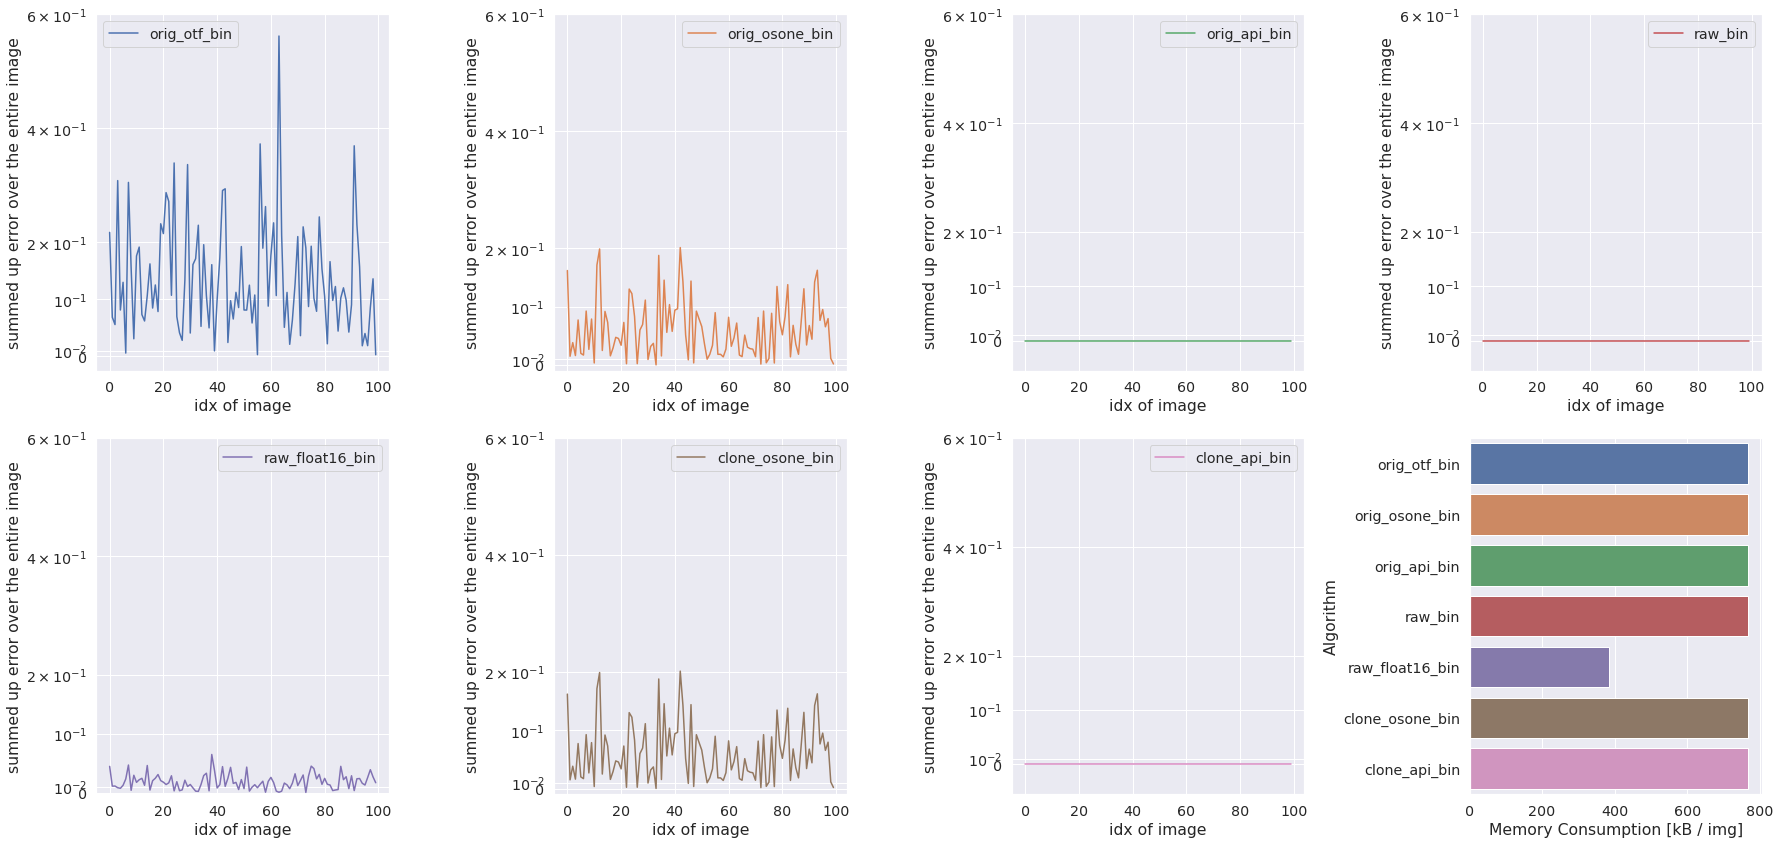

In [148]:
df_memory = pd.DataFrame({'Algorithm': df.columns, 'Memory Consumption [kB / img]': [768,768,768,768,384,768,768]})

fig, axs = plt.subplots(2,4, figsize=(25,12))
axs = axs.ravel()

for num, key in enumerate(df.columns):
    sns.lineplot(data=df, x=df.index, y=key, ax=axs[num], label=key, color=sns.color_palette()[num])
    axs[num].set_yscale("symlog")
    axs[num].set_yticks((0.0, 1e-2, 1e-1, 0.2e0, 0.4e0, 0.6e0))
    axs[num].set_xlabel("idx of image")
    axs[num].set_ylabel("summed up error over the entire image")
sns.barplot(data=df_memory, x="Memory Consumption [kB / img]",y="Algorithm",  ax=axs[7], orient="h")
plt.tight_layout()

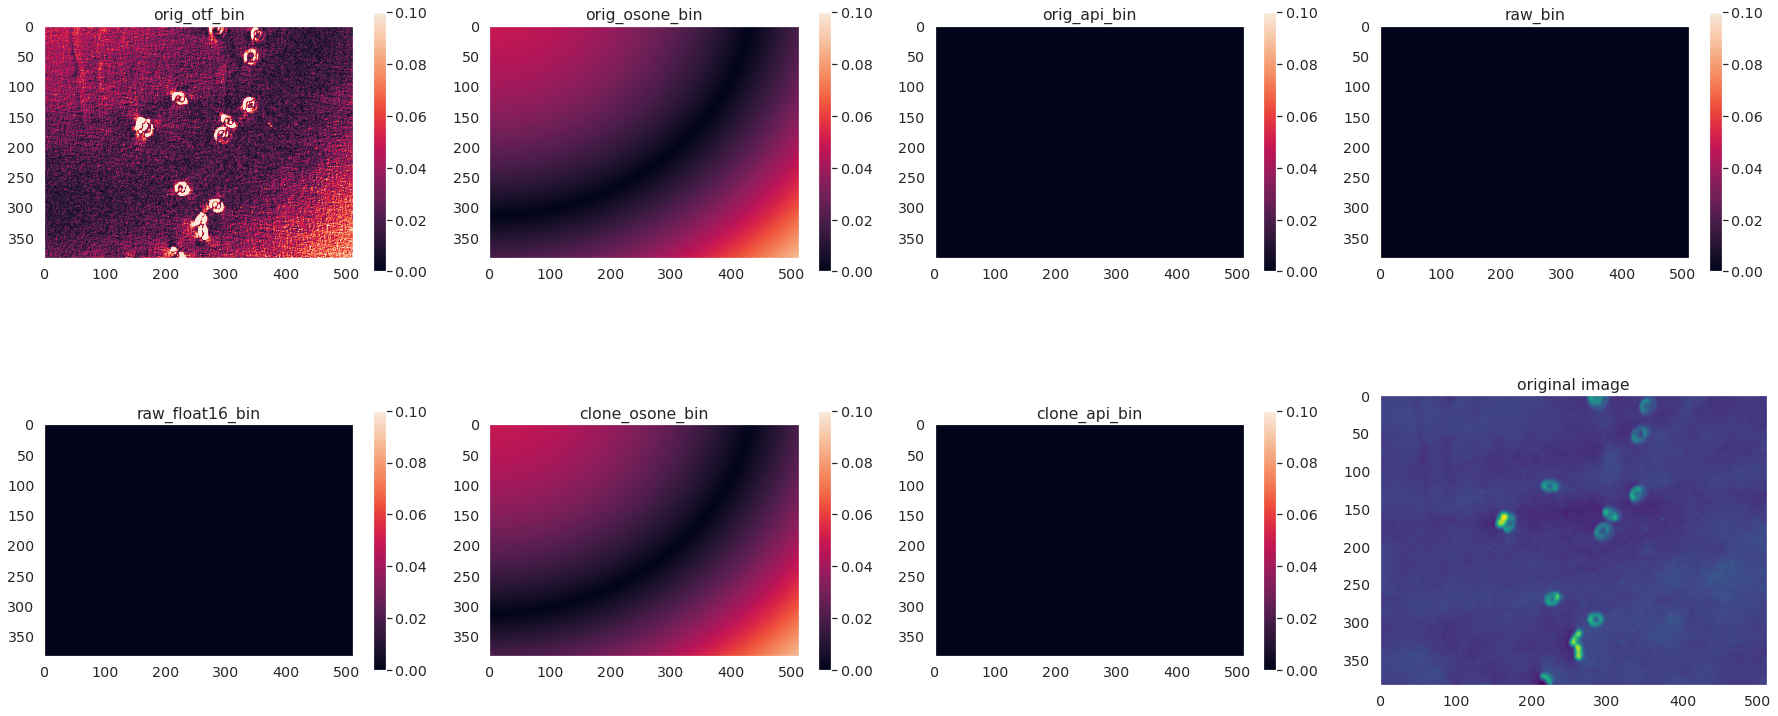

In [198]:
fig, axs = plt.subplots(2,4, figsize=(25,12))
axs = axs.ravel()
i=25
ground_truth = BinFile("phase").location(bin_path_template_dict["orig_api_bin"](image_number=i+1)).read()
for num, (name, path) in enumerate(bin_path_template_dict.items()):
    bin = BinFile("phase").location(path(image_number=i+1)).read()
    im = axs[num].imshow(np.abs(ground_truth - bin), vmin=0, vmax=0.1)
    axs[num].grid(None)
    fig.colorbar(im, ax=axs[num], shrink=0.6)
    axs[num].set_title(name)

axs[7].imshow(ground_truth, cmap="viridis")
axs[7].grid(None)
axs[7].set_title("original image")
plt.tight_layout()